Rising flank 0: from index 1323 to 1353
Rising flank 1: from index 2452 to 2482
Rising flank 2: from index 3441 to 3475


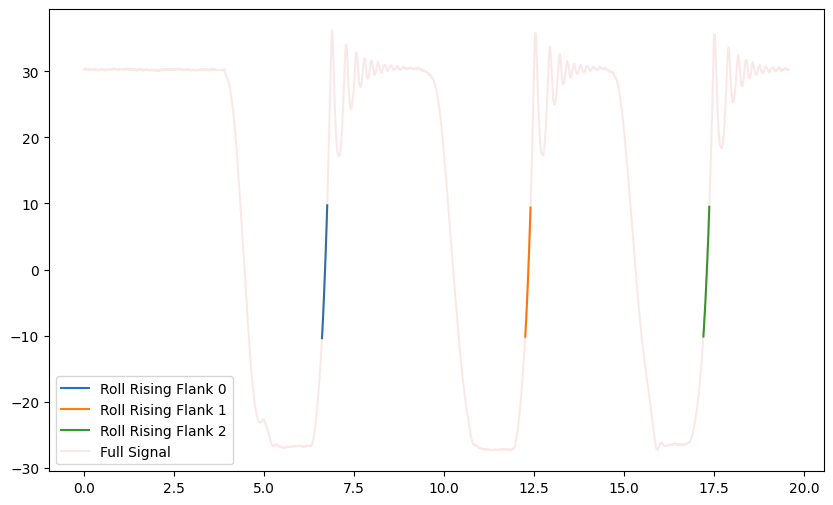

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def detect_rising_flank(signal, max_dips, rise_start_range, rising_end):
    """
    Detect rising flanks in a 1D array/Series allowing up to `max_dips` consecutive non-rising samples,
    and only start rising when the increase exceeds `delta_min`.
    
    Returns a boolean mask of same length as signal.
    """
    count_dips = 0
    rising = False
    rising_start_index = None

    rises = []

    for i in range(1, len(signal)):
        diff = signal[i] - signal[i - 1]

        if rising:
            if signal[i] > rising_end or (diff <= 0 and (count_dips := count_dips + 1) > max_dips):
                rises.append([rising_start_index, i])
                rising = False
                count_dips = 0
            elif diff <= 0:
                count_dips += 1
            else:
                count_dips = 0
        else:
            if signal[i] > rise_start_range[0] and signal[i] <= rise_start_range[1] and diff > 0:
                if (count_dips := count_dips + 1) > max_dips:
                    rising = True
                    rising_start_index = i - count_dips
                    count_dips = 0
            else:
                count_dips = 0

    return rises

# Example usage with CSV
df = pd.read_csv("measurements_roll/measurements_roll_12N_0.2Nm.csv")

# Detect rising flanks on 'roll' column
rises = detect_rising_flank(df["roll_deg"], max_dips=5, rise_start_range=(-10, 0), rising_end=10)

plt.figure(figsize=(10, 6))

for i, rise in enumerate(rises):
    selected_part = df.iloc[rise[0]:rise[1]]
    print(f"Rising flank {i}: from index {rise[0]} to {rise[1]}")

    plt.plot(selected_part["timestamp_iso"], selected_part["roll_deg"], label=f"Roll Rising Flank {i}")

plt.plot(df["timestamp_iso"], df["roll_deg"], alpha=0.1, label="Full Signal")
plt.legend()
plt.show()

Mean Squared Error: 1.6682045671359282e-31
Winkelbeschleunigung: 516.5378197997924


<Figure size 1000x600 with 0 Axes>

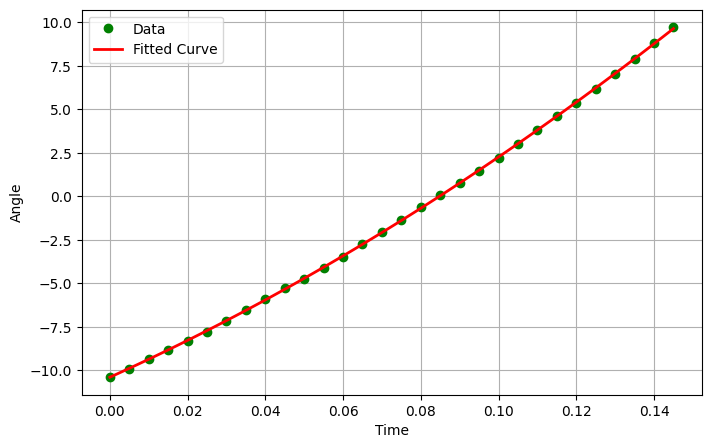

Mean Squared Error: 2.230545296017891e-31
Winkelbeschleunigung: 549.4601486605501


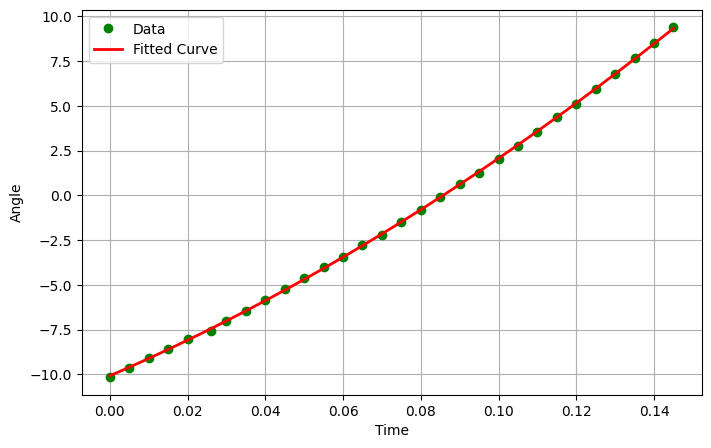

Mean Squared Error: 2.414782160375044e-31
Winkelbeschleunigung: 453.40416793234095


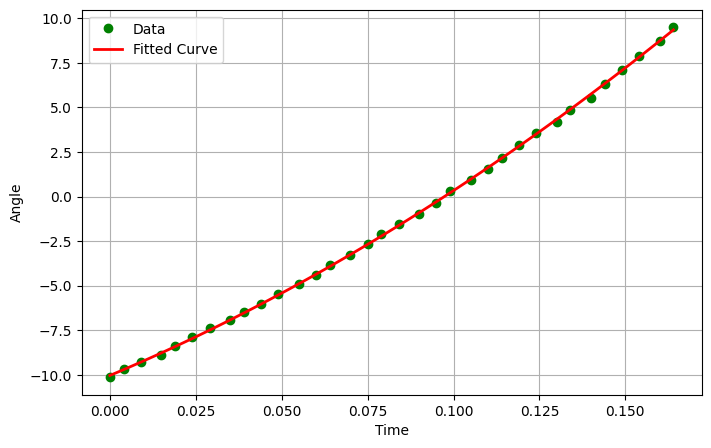

In [9]:
def fit_quadratic(x, y):
    # polynomial fit on selected range
    coeffs = np.polyfit(x, y, 2)

    mse = np.mean(y - np.polyval(coeffs, x))**2 / np.size(y)
    print(f"Mean Squared Error: {mse}")

    print(f"Winkelbeschleunigung: {2 * coeffs[0]}")

    plt.figure(figsize=(8,5))
    plt.plot(x, y, 'go', label='Data')

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot the quadratic fit
    plt.plot(x_fit, y_fit, 'r-', linewidth=2, label='Fitted Curve')

    plt.xlabel('Time')
    plt.ylabel('Angle')
    plt.legend()
    plt.grid(True)
    plt.show()


plt.figure(figsize=(10, 6))

for i in range(len(rises)):
    selected_part = df.iloc[rises[i][0]:rises[i][1]]

    fit_quadratic(selected_part["timestamp_iso"] - selected_part["timestamp_iso"].iloc[0], selected_part["roll_deg"])


In [12]:
M = 1.014
d_roll_pitch = 0.4
d_yaw = 0.24
h = 2.29
g = 9.81

T_roll = [2.40, 2.53, 2.41, 2.37, 2.36, 2.37, 2.44, 2.25, 2.38, 2.47, 
          2.28, 2.38, 2.50, 2.29, 2.38, 2.42, 2.40, 2.40, 2.35, 2.13,
          2.78, 2.29, 2.68, 2.60, 2.42, 2.41, 2.31, 2.51, 2.34, 2.25,
          2.68, 2.59, 2.46, 2.46, 2.47, 2.41, 2.37, 2.36, 2.36, 2.54]

T_pitch = [2.79, 2.54, 2.41, 2.60, 2.47, 2.44, 2.44, 2.57, 2.30, 2.38,
           2.53, 2.35, 2.63, 2.44, 2.51, 2.48, 2.44, 2.53, 2.30, 2.41,
           2.62, 2.57, 2.44, 2.48, 2.57, 2.32, 2.44, 2.35, 2.63, 2.26,
           2.22, 2.69, 2.50, 2.47, 2.38, 2.63, 2.40, 2.45, 2.45, 2.35]

T_yaw = [
    6.76, 6.54, 6.48, 6.09, 6.28, 6.25,
    7.25, 7.08, 6.98, 6.63, 6.47, 6.38,
    7.22, 7.22, 6.70, 6.72, 6.53, 6.09,
    6.61, 6.29, 6.13, 6.19, 5.95, 6.32,
]

def identify_inertia(T_values, d):
    T_mean = np.mean(T_values)
    print(f"Mean T: {T_mean}")

    def T_to_I(T):
        return (M * g * d ** 2 * T ** 2) / (16 * np.pi ** 2 * h)

    inertia = T_to_I(T_mean)

    return inertia

Ixx = identify_inertia(T_roll, d_roll_pitch)
Iyy = identify_inertia(T_pitch, d_roll_pitch)
Izz = identify_inertia(T_yaw, d_yaw)

print(f"Identified Inertia Ixx: {Ixx}")  # in kg*m^2
print(f"Identified Inertia Iyy: {Iyy}")  # in kg*m^2
print(f"Identified Inertia Izz: {Izz}")  # in kg*m^2


Mean T: 2.42
Mean T: 2.4694999999999996
Mean T: 6.548333333333333
Identified Inertia Ixx: 0.02577522509172591
Identified Inertia Iyy: 0.02684045017415823
Identified Inertia Izz: 0.06794160346376639
